<a href="https://colab.research.google.com/github/abineshabi1027/FUTURE_DS_01/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_1970/3317298674.py:83: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Retained', 'Churned'])
/tmp/ipykernel_1970/3317298674.py:88: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='SupportTickets', y='Churned', errorbar=None, palette='Reds', ax=ax3)


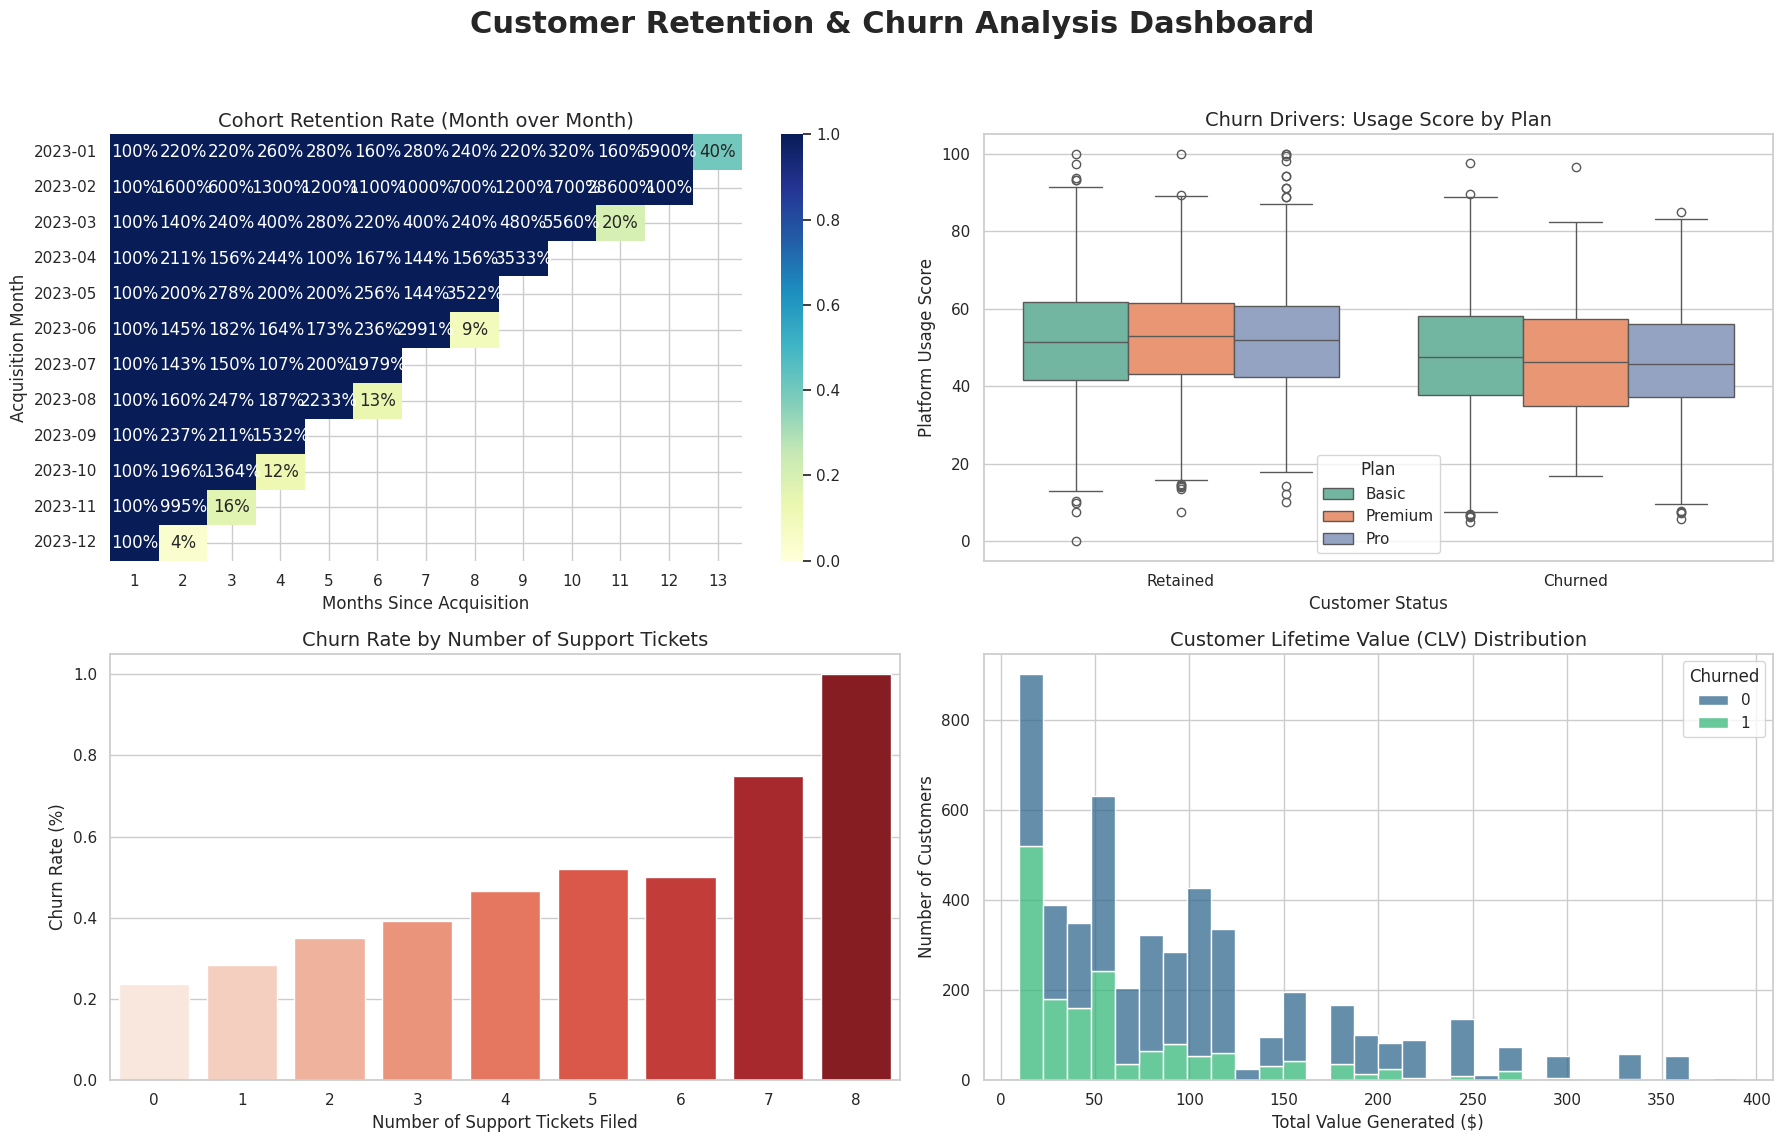

-- SUMMARY STATISTICS --
Total Customers: 5000
Overall Churn Rate: 31.82%
Average Customer Lifetime Value: $94.50

-- CHURN BY PLAN --
Plan
Basic      32.275542
Premium    32.413088
Pro        30.598053
Name: Churned, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

np.random.seed(42)

n_customers = 5000
start_date = pd.to_datetime('2023-01-01')
end_date = pd.to_datetime('2023-12-31')

customer_ids = range(1, n_customers + 1)
signup_dates = [start_date + timedelta(days=np.random.randint(0, 365)) for _ in range(n_customers)]

subs_types = ['Basic', 'Pro', 'Premium']
monthly_fees = {'Basic': 9.99, 'Pro': 19.99, 'Premium': 29.99}
customer_subs = np.random.choice(subs_types, n_customers, p=[0.5, 0.3, 0.2])

support_tickets = np.random.poisson(lam=1.5, size=n_customers)
usage_score = np.random.normal(loc=50, scale=15, size=n_customers).clip(0, 100)

churn_probability = (support_tickets * 0.05) + ((100 - usage_score) * 0.005)
is_churned = np.random.binomial(1, churn_probability.clip(0, 0.9))

last_active_dates = []
for i in range(n_customers):
    if is_churned[i]:
        days_active = np.random.randint(1, (end_date - signup_dates[i]).days + 2)
        last_active_dates.append(signup_dates[i] + timedelta(days=days_active))
    else:
        last_active_dates.append(end_date)

df = pd.DataFrame({
    'CustomerID': customer_ids,
    'SignupDate': signup_dates,
    'LastActiveDate': last_active_dates,
    'Plan': customer_subs,
    'MonthlyFee': [monthly_fees[plan] for plan in customer_subs],
    'SupportTickets': support_tickets,
    'UsageScore': usage_score,
    'Churned': is_churned
})

df['LifespanMonths'] = ((df['LastActiveDate'] - df['SignupDate']).dt.days / 30).apply(np.ceil).clip(lower=1)

df['CLV'] = df['LifespanMonths'] * df['MonthlyFee']

df['CohortMonth'] = df['SignupDate'].dt.to_period('M')
df['ActiveMonth'] = df['LastActiveDate'].dt.to_period('M')

def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    return year, month

signup_year, signup_month = get_date_int(df, 'CohortMonth')
active_year, active_month = get_date_int(df, 'ActiveMonth')

years_diff = active_year - signup_year
months_diff = active_month - signup_month
df['CohortIndex'] = years_diff * 12 + months_diff + 1

cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

cohort_sizes = cohort_counts.iloc[:, 0]
retention_matrix = cohort_counts.divide(cohort_sizes, axis=0)

sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))
fig.suptitle('Customer Retention & Churn Analysis Dashboard', fontsize=22, fontweight='bold')

ax1 = plt.subplot(2, 2, 1)
sns.heatmap(retention_matrix, annot=True, fmt='.0%', cmap='YlGnBu', vmin=0.0, vmax=1.0, ax=ax1)
ax1.set_title('Cohort Retention Rate (Month over Month)', fontsize=14)
ax1.set_ylabel('Acquisition Month')
ax1.set_xlabel('Months Since Acquisition')

ax2 = plt.subplot(2, 2, 2)
sns.boxplot(data=df, x='Churned', y='UsageScore', hue='Plan', palette='Set2', ax=ax2)
ax2.set_title('Churn Drivers: Usage Score by Plan', fontsize=14)
ax2.set_xticklabels(['Retained', 'Churned'])
ax2.set_xlabel('Customer Status')
ax2.set_ylabel('Platform Usage Score')

ax3 = plt.subplot(2, 2, 3)
sns.barplot(data=df, x='SupportTickets', y='Churned', errorbar=None, palette='Reds', ax=ax3)
ax3.set_title('Churn Rate by Number of Support Tickets', fontsize=14)
ax3.set_xlabel('Number of Support Tickets Filed')
ax3.set_ylabel('Churn Rate (%)')

ax4 = plt.subplot(2, 2, 4)
sns.histplot(data=df, x='CLV', hue='Churned', multiple="stack", bins=30, palette='viridis', ax=ax4)
ax4.set_title('Customer Lifetime Value (CLV) Distribution', fontsize=14)
ax4.set_xlabel('Total Value Generated ($)')
ax4.set_ylabel('Number of Customers')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("-- SUMMARY STATISTICS --")
print(f"Total Customers: {len(df)}")
print(f"Overall Churn Rate: {df['Churned'].mean() * 100:.2f}%")
print(f"Average Customer Lifetime Value: ${df['CLV'].mean():.2f}")
print("\n-- CHURN BY PLAN --")
print(df.groupby('Plan')['Churned'].mean() * 100)